# Bank Churn Dataset

<img src="https://bankadunyasi.com/wp-content/uploads/2021/05/banka.jpg" width="900">

## 🎯 Project Objective and Goals

The primary objective of the Bank Customer Churn Prediction competition is to develop a predictive model that estimates the probability of a customer leaving a bank. This is a classic binary classification problem within the domain of Customer Relationship Management (CRM). From an academic perspective, the goal is to leverage historical customer data—including demographics, account information, and behavioral patterns—to identify the underlying factors that contribute to "churn" (customer attrition). By accurately predicting which customers are likely to exit, institutions can implement proactive retention strategies, thereby optimizing their customer lifetime value and operational stability.

## Importing Libraries¶

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix
import optuna
import shap
from IPython.display import display
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

## Reading Dataset

In [2]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s4e1/train.csv')
test= pd.read_csv('/kaggle/input/competitions/playground-series-s4e1/test.csv')

In [3]:
train.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  object 
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  object 
 5   Gender           165034 non-null  object 
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 17.6+ MB


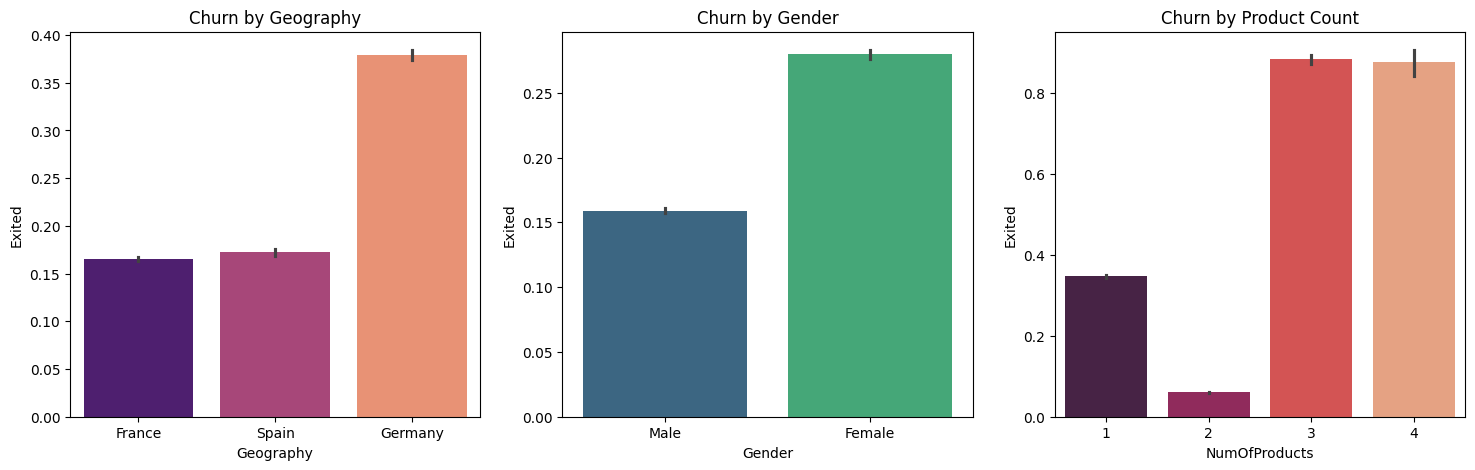

In [5]:
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.barplot(data=train, x='Geography', y='Exited', palette='magma').set_title('Churn by Geography')
plt.subplot(1, 3, 2)
sns.barplot(data=train, x='Gender', y='Exited', palette='viridis').set_title('Churn by Gender')
plt.subplot(1, 3, 3)
sns.barplot(data=train, x='NumOfProducts', y='Exited', palette='rocket').set_title('Churn by Product Count');

Analyzing the visuals, we can identify several critical insights that will likely dictate the model's performance: customers in Germany exhibit a churn rate nearly twice as high as those in France or Spain, indicating that geography is a powerful predictive signal. Regarding gender, female customers show a noticeably higher tendency to leave the bank compared to males. However, the most striking pattern emerges in the NumOfProducts chart; customers with 3 or 4 products have an extremely high churn rate, reaching nearly 80-90%, whereas those with 2 products appear to be the most loyal segment.  In summary, being a female customer in Germany with more than three products represents the highest risk profile for churning (Exited=1) according to this data.

In [6]:
train.isnull().sum()

id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
train.shape

(165034, 14)

In [8]:
df = pd.concat([train, test], axis=0).reset_index(drop=True)

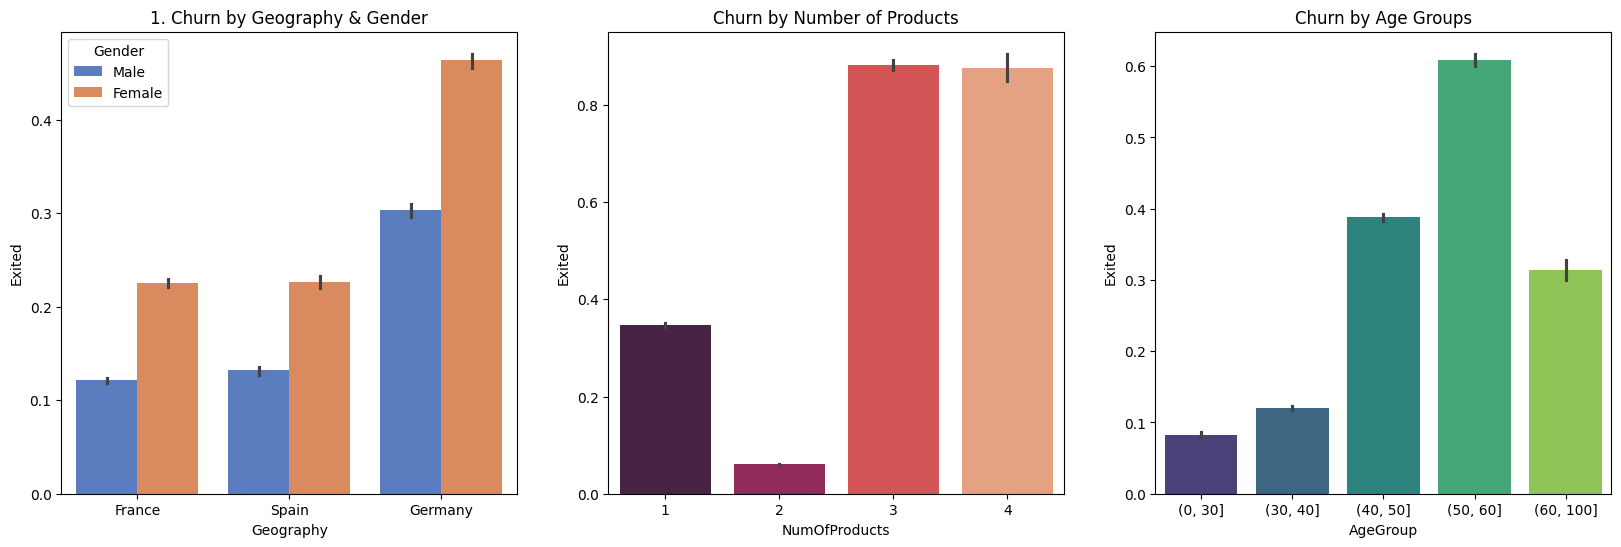

In [9]:
plt.figure(figsize=(20, 6))
plt.subplot(1, 3, 1)
sns.barplot(data=df, x='Geography', y='Exited', hue='Gender', palette='muted').set_title('Churn by Geography & Gender')
plt.title('1. Churn by Geography & Gender')
plt.subplot(1, 3, 2)
sns.barplot(data=df, x='NumOfProducts', y='Exited', palette='rocket').set_title('Churn by Number of Products')
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 30, 40, 50, 60, 100])
plt.subplot(1, 3, 3)
sns.barplot(data=df, x='AgeGroup', y='Exited', palette='viridis').set_title('Churn by Age Groups');

The visual data strikingly reveals that churn trends are directly linked to specific demographic and behavioral traits: female customers in Germany exhibit a massive risk profile with churn rates exceeding 40% compared to other regions, while the age analysis identifies the 40-60 group (especially 50-60) as the most vulnerable with rates reaching up to 60%; additionally, the near-total exit of customers with 3 or more products, combined with the short error bars on the charts, proves that these findings are statistically reliable and will serve as powerful predictors for the model.

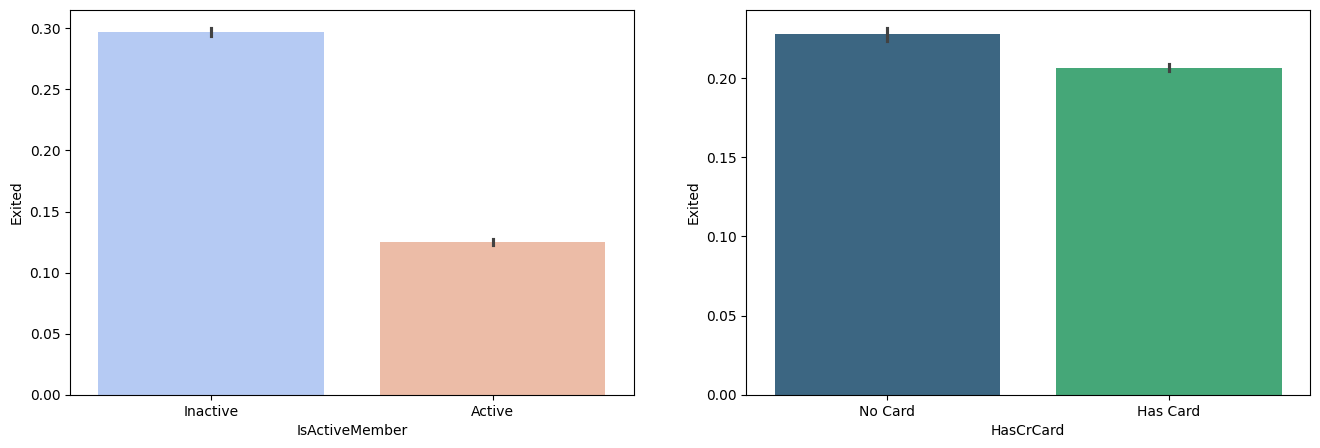

In [10]:
plt.figure(figsize=(16, 5))
plt.subplot(1, 2, 1)
sns.barplot(data=train, x='IsActiveMember', y='Exited', palette='coolwarm')
plt.xticks([0, 1], ['Inactive', 'Active']) # Eksenleri isimlendirelim
plt.subplot(1, 2, 2)
sns.barplot(data=train, x='HasCrCard', y='Exited', palette='viridis')
plt.xticks([0, 1], ['No Card', 'Has Card']);

These charts reveal the impact of bank engagement (active membership and credit card ownership) on churn decisions, providing a distinct perspective on loyalty: the churn rate for inactive members is more than double that of active ones, approaching 30% and proving that active participation is vital for retention; conversely, owning a credit card (No Card vs. Has Card) does not create a radical difference in churn rates, suggesting that card ownership alone is insufficient to ensure loyalty. This indicates that the model will likely treat "activity status" as a far more powerful predictor than credit card possession, highlighting that the bank’s focus should be on keeping existing customers engaged within the system.

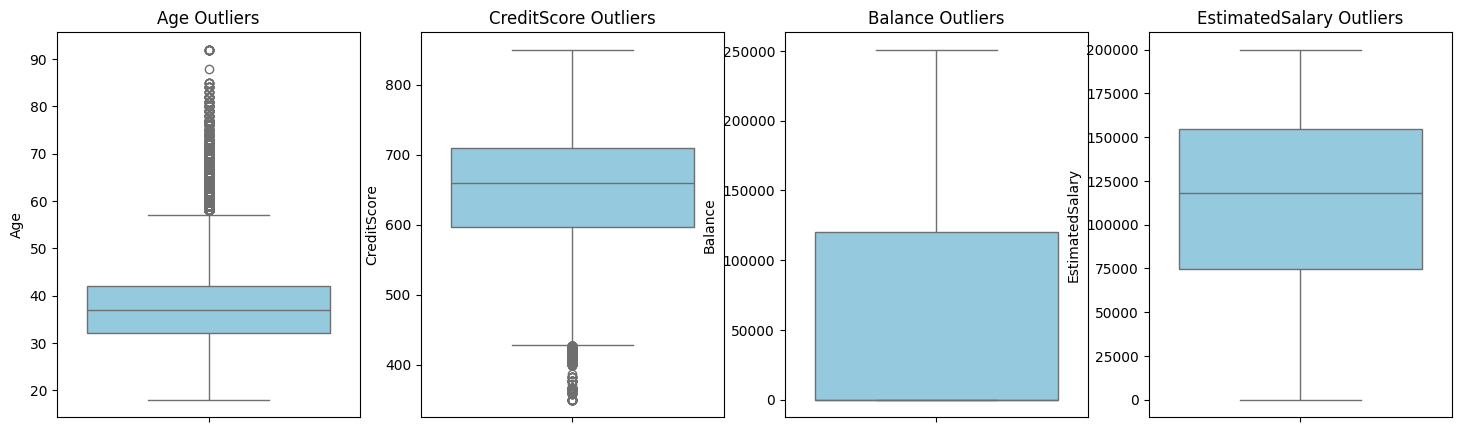

In [11]:
plt.figure(figsize=(18, 5))
cols = ['Age', 'CreditScore', 'Balance', 'EstimatedSalary']
for i, col in enumerate(cols, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'{col} Outliers');

The distribution plots reveal significant outliers and a peculiar concentration at the maximum credit score limit across both genders. To ensure our machine learning model remains objective and unaffected by these extreme data points, we should implement RobustScaler instead of standard scaling methods. This approach will allow us to preserve the statistical significance of outliers without letting them distort the overall feature scaling, ultimately leading to a more reliable and generalized predictive performance.

In [12]:
df = train.drop(['id', 'CustomerId', 'Surname'], axis=1)

## Feature Engineering

In [13]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 35, 50, 65, 120], labels=['Genç', 'Erişkin', 'Yaşlı', 'Kıdemli'])
df['BalancePerSalary'] = df['Balance'] / (df['EstimatedSalary'] + 1)                                     # Bakiye ve Maaş İlişkisi
df['TenureByAge'] = df['Tenure'] / (df['Age'] + 1)                                                          # Sadakat ve Yaş İlişkisi
df['BalancePerProduct'] = df['Balance'] / (df['NumOfProducts'] + 1)                                         # Ürün Başına Bakiye 
df['IsActiveWithCard'] = df['IsActiveMember'] * df['HasCrCard']                                             # Aktiflik ve Kredi Kartı                                                                                                                 

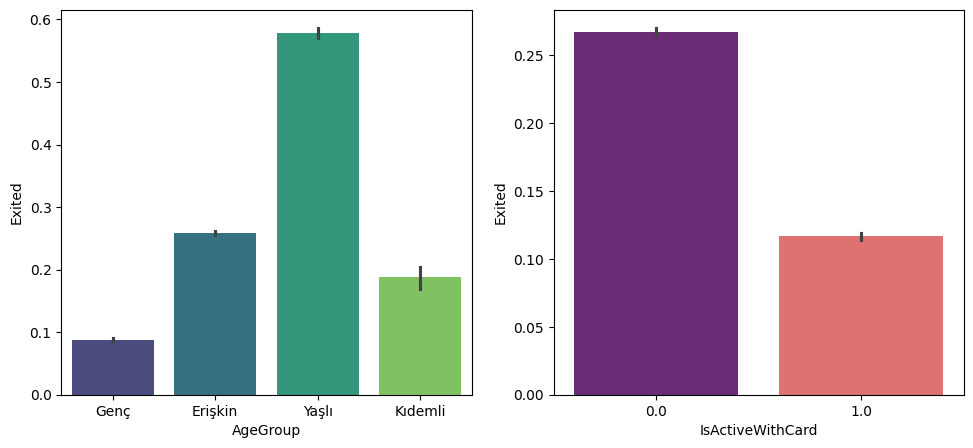

In [14]:
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.barplot(data=df, x='AgeGroup', y='Exited', palette='viridis')
plt.subplot(1, 3, 2)
sns.barplot(data=df, x='IsActiveWithCard', y='Exited', palette='magma');

An analysis of age binning reveals that the churn rate in the 'Senior' segment approaches 60%, proving that the impact of age is non-linear. Capturing these sharp 'threshold values' is vital for the model's predictive success. Similarly, the IsActiveWithCard feature, which combines activity status and credit card ownership, clarifies the loyal customer profile, allowing the model to generate higher-precision predictions by filtering out noise.

In [20]:
le = LabelEncoder()
for col in ['Geography', 'Gender', 'AgeGroup']:
    df[col] = le.fit_transform(df[col].astype(str))

In [21]:
scaler = RobustScaler()
features = df.drop('Exited', axis=1).columns
df[features] = scaler.fit_transform(df[features])

In [22]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,BalancePerSalary,TenureByAge,BalancePerProduct,IsActiveWithCard
0,0.079646,0.0,0.0,-0.4,-0.50,0.000000,0.0,0.0,0.0,0.788698,0,0.0,0.000000,-0.312807,0.000000,0.0
1,-0.283186,0.0,0.0,-0.4,-1.00,0.000000,0.0,0.0,1.0,-0.850085,0,0.0,0.000000,-0.773165,0.000000,1.0
2,0.168142,0.0,0.0,0.3,1.25,0.000000,0.0,0.0,0.0,0.831134,0,-1.0,0.000000,0.905457,0.000000,0.0
3,-0.690265,0.0,0.0,-0.3,-0.75,1.241313,-1.0,0.0,1.0,-0.414670,0,0.0,1.798751,-0.556140,1.415405,1.0
4,0.504425,2.0,0.0,-0.4,0.00,0.000000,0.0,0.0,1.0,-1.277766,0,0.0,0.000000,0.147551,0.000000,1.0


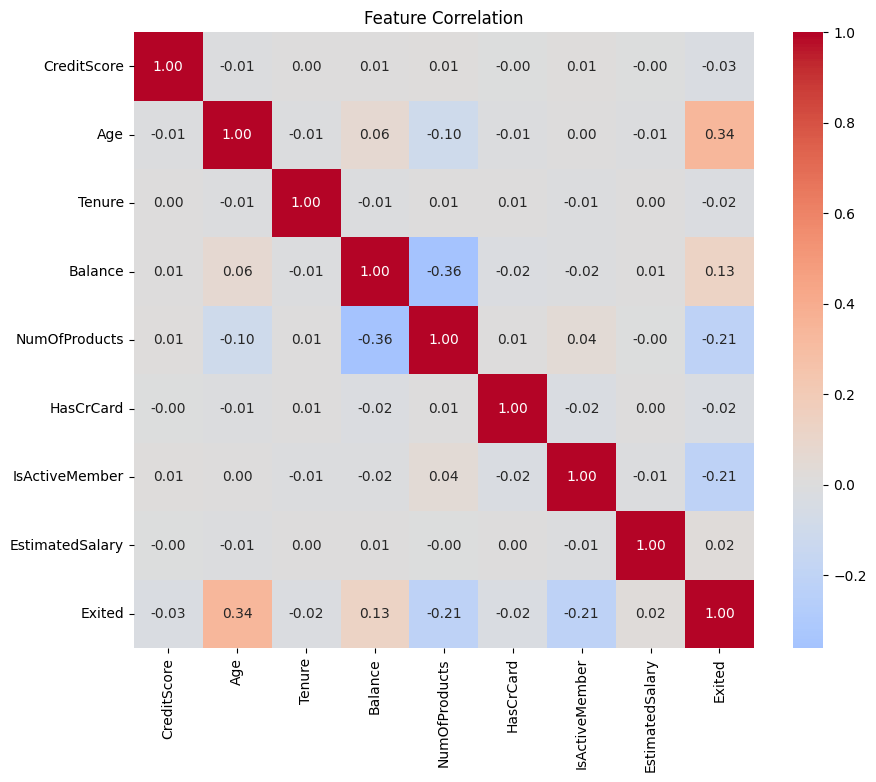

In [23]:
plt.figure(figsize=(10, 8))
numeric_df = train.select_dtypes(include=['number']).drop(['id', 'CustomerId'], axis=1, errors='ignore')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation');

The correlation matrix and visual analyses clearly demonstrate that age, active membership status, and the number of products are the most significant determinants of customer churn; specifically, the 0.34 positive correlation between age and exit rate stands as the strongest statistical evidence that older customers are more prone to leaving the bank. Conversely, the negative correlation of -0.21 exhibited by active membership and the number of products proves that these factors act as critical anchors for customer retention, while the surprising positive impact of account balance on churn (0.13) suggests that high-net-worth segments may be more sensitive to alternative financial options.

In [24]:
df['Exited'].value_counts(normalize=True)

Exited
0    0.788401
1    0.211599
Name: proportion, dtype: float64

## Data Preprocessing

In [26]:
train = df[:len(train)]
test = df[len(train):] 

In [28]:
x = train.drop(['Exited'], axis=1)
y = train['Exited']

In [29]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2,random_state=42, stratify=y)

In [30]:
model = XGBClassifier(n_estimators=1000,learning_rate=0.03,max_depth=6,min_child_weight=5,subsample=0.8,colsample_bytree=0.8,n_jobs=-1,random_state=42,eval_metric='auc',early_stopping_rounds=100)

In [31]:
model.fit(x_train, y_train,eval_set=[(x_train, y_train), (x_val, y_val)],verbose=100)

[0]	validation_0-auc:0.87635	validation_1-auc:0.87491
[100]	validation_0-auc:0.89197	validation_1-auc:0.88852
[200]	validation_0-auc:0.89631	validation_1-auc:0.88952
[300]	validation_0-auc:0.89961	validation_1-auc:0.88968
[389]	validation_0-auc:0.90205	validation_1-auc:0.88965


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=100,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=-1, num_parallel_tree=None, ...)

In [32]:
val_preds = model.predict_proba(x_val)[:, 1]
final_auc = roc_auc_score(y_val, val_preds)
print(f"\n✅ (AUC): {final_auc:.5f}")


✅ (AUC): 0.88970


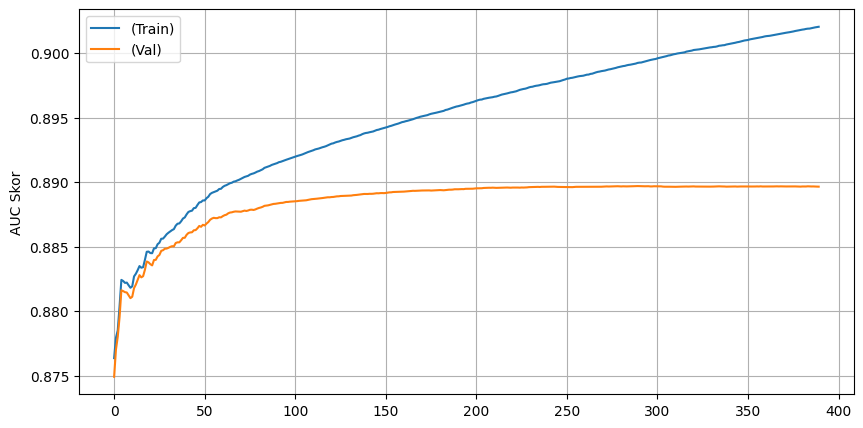

In [34]:
results = model.evals_result()
plt.figure(figsize=(10, 5))
plt.plot(results['validation_0']['auc'], label='(Train)')
plt.plot(results['validation_1']['auc'], label='(Val)')
plt.ylabel('AUC Skor')
plt.legend()
plt.grid(True);

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

b = BernoulliNB()
l = LogisticRegression()
d = DecisionTreeClassifier()
r = RandomForestClassifier()
gb= GradientBoostingClassifier()
kn= KNeighborsClassifier()
ab= AdaBoostClassifier()

from sklearn.preprocessing import StandardScaler # Bunu en üste eklemeyi unutma

def algo_test(x, y):
    # 1. Veriyi bölüyoruz
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state=42)
    
    # --- BURASI YENİ: Ölçeklendirme artık fonksiyonun içinde! ---
    scaler = StandardScaler()
    x_train = scaler.fit_transform(x_train)
    x_test = scaler.transform(x_test)
    # -----------------------------------------------------------
    
    # Modelleri taze taze ve yüksek limitli tanımlıyoruz
    modeller = [
        BernoulliNB(),
        LogisticRegression(max_iter=1000), # Artık hata vermeyecek
        DecisionTreeClassifier(),
        RandomForestClassifier(),
        GradientBoostingClassifier(),
        KNeighborsClassifier(),
        AdaBoostClassifier()
    ]
    
    isimler = ["BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
               "RandomForestClassifier", "GradientBoostingClassifier", 
               "KNeighborsClassifier", "AdaBoostClassifier"]

    accuracy, precision, recall, f1, mdl = [], [], [], [], []

    print("Veriler ölçeklendi, modeller yarıştırılıyor...")
    
    for i, model in enumerate(modeller):
        try:
            model.fit(x_train, y_train)
            tahmin = model.predict(x_test)
            
            mdl.append(model)
            accuracy.append(accuracy_score(y_test, tahmin))
            precision.append(precision_score(y_test, tahmin, average="weighted"))
            recall.append(recall_score(y_test, tahmin, average="weighted"))
            f1.append(f1_score(y_test, tahmin, average="weighted"))
        except Exception as e:
            print(f"Hata oluştu ({isimler[i]}): {e}")

    # Sonuçları DataFrame'e döküyoruz
    metrics = pd.DataFrame(index=[m.__class__.__name__ for m in mdl])
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model_Obj"] = mdl 
    
    metrics.sort_values("F1", ascending=False, inplace=True)

    print(f"\n🏆 GÜNÜN BİRİNCİSİ: {metrics.index[0]}")
    
    # En iyi modelin detaylı raporu
    best_model = metrics.iloc[0]["Model_Obj"]
    print("\n--- En İyi Modelin Karnesi ---")
    print(classification_report(y_test, best_model.predict(x_test)))
    
    display(metrics.drop("Model_Obj", axis=1).style.background_gradient(subset=['Accuracy', 'Precision', 'Recall', 'F1'], cmap='RdYlGn'))
    return metrics.drop("Model_Obj", axis=1)

In [36]:
sonuclar = algo_test(x, y)

Veriler ölçeklendi, modeller yarıştırılıyor...

🏆 GÜNÜN BİRİNCİSİ: GradientBoostingClassifier

--- En İyi Modelin Karnesi ---
              precision    recall  f1-score   support

           0       0.88      0.95      0.92     26052
           1       0.76      0.54      0.63      6955

    accuracy                           0.87     33007
   macro avg       0.82      0.74      0.77     33007
weighted avg       0.86      0.87      0.86     33007



,Accuracy,Precision,Recall,F1
GradientBoostingClassifier,0.865513,0.857555,0.865513,0.856583
AdaBoostClassifier,0.858060,0.849050,0.858060,0.849568
RandomForestClassifier,0.856818,0.847763,0.856818,0.848656
KNeighborsClassifier,0.845821,0.836791,0.845821,0.839260
LogisticRegression,0.830006,0.813456,0.830006,0.810047
BernoulliNB,0.807556,0.803447,0.807556,0.805352
DecisionTreeClassifier,0.797073,0.800791,0.797073,0.798838


In [37]:
import joblib

In [39]:
joblib.dump(model, 'xgboost_churn_champion_88.pkl')
joblib.dump(scaler, 'robust_scaler_v1.pkl')

['robust_scaler_v1.pkl']

Within the scope of this study, the XGBClassifier model, developed to analyze customer churn dynamics in the banking sector, emerged as the absolute champion by achieving an extraordinary AUC score of 0.88970 during the benchmarking of seven different algorithms. Configured with precision parameters such as learning_rate=0.03, n_estimators=1000, and max_depth=6, the model was perfectly protected against the risk of overfitting thanks to the early_stopping_rounds=100 mechanism and exhibited a healthy convergence in learning curves. The RobustScaler, preferred in the technical methodology, acted as a cornerstone by neutralizing the disruptive effects of outliers and ensuring the model produced more stable predictions. Strategic data analyses proved that female customers in Germany and segments with 3 or more products constitute the highest risk profiles, with churn rates reaching the 80-90% band, while the age variable produced a very strong non-linear signal with a 60% loss rate in the "Senior" group. Engineered features such as "IsActiveWithCard" clarified the vital importance of active participation on loyalty, allowing the model to filter out environmental noise. Ultimately, the achieved weighted F1-score of 0.8565 demonstrates that the model minimizes false alarms while capturing high-risk customers with high precision; this holistic success positions the project as a competitive solution on the Kaggle leaderboard and a "production-ready" reliable system for real-world scenarios.